## Homework1

### author: zg137

### Question 1

#### (1)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


DATA_PATH = "Concrete_Data_Yeh.csv"

In [14]:
df = pd.read_csv(DATA_PATH)

print("Data shape:", df.shape)
display(df.head())
print("Column names:", list(df.columns))

Data shape: (1030, 9)


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


Column names: ['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age', 'csMPa']


In [16]:
target_col = 'csMPa'
feature_cols = df.columns[:-1]

X_raw = df[feature_cols].astype(float).values
y = df[target_col].astype(float).values.reshape(-1, 1)

In [18]:
def add_bias(X):
    N = X.shape[0]
    b = np.ones((N, 1))
    return np.hstack([b, X])

X = X_raw.copy()
X_b = add_bias(X)

**Gradient derivation for linear regression (MSE loss)**

Let $X \in \mathbb{R}^{N\times d}$ be the design matrix (including bias),
$\beta \in \mathbb{R}^{d\times 1}$ the parameter vector, and
$y \in \mathbb{R}^{N\times 1}$ the target vector.  
The linear regression model is
$$
\hat{y} = X\beta.
$$

The MSE loss is defined as
$$
L(\beta) = \|y - X\beta\|_2^2.
$$

Equals to:
$$
L(\beta) = (y - X\beta)^\top (y - X\beta).
$$

Taking the gradient with respect to $\beta$ gives:
$$
\nabla_\beta L = -2X^\top (y - X\beta).
$$

Setting the gradient to zero, we have:
$$
X^\top X \beta = X^\top y.
$$

If $X^\top X$ is invertible, the solution is
$$
\beta = (X^\top X)^{-1} X^\top y.
$$

Here, this solution can be computed using the Moore--Penrose pseudoinverse:
$$
\beta = X^{+} y.
$$


In [27]:
def closed_form_beta(X, y):
    '''
    Using the Moore-Penrose pseudoinverse:
    β = X⁺ y
    '''
    return np.linalg.pinv(X) @ y

beta = closed_form_beta(X_b, y)

print('β dimensions:', beta.shape)


β dimensions: (9, 1)


#### (2)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Divide the dataset into training and validation sets
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, shuffle=True
)

In [29]:
# i = 7
selected_idx_7 = [0, 1, 2, 3, 4, 7]

X_train_7 = X_train_raw[:, selected_idx_7]
X_val_7   = X_val_raw[:, selected_idx_7]

X_train_7_b = add_bias(X_train_7)
X_val_7_b   = add_bias(X_val_7)

beta_7 = closed_form_beta(X_train_7_b, y_train)
y_val_pred_7 = X_val_7_b @ beta_7
mse_7 = mean_squared_error(y_val, y_val_pred_7)

print('Using selected 7 features, mse is:', mse_7)


Using selected 7 features, mse is: 95.64230794848474


In [30]:
# i = 8
selected_idx_8 = [0, 1, 2, 3, 4, 5, 7]

X_train_8 = X_train_raw[:, selected_idx_8]
X_val_8   = X_val_raw[:, selected_idx_8]

X_train_8_b = add_bias(X_train_8)
X_val_8_b   = add_bias(X_val_8)

beta_8 = closed_form_beta(X_train_8_b, y_train)
y_val_pred_8 = X_val_8_b @ beta_8
mse_8 = mean_squared_error(y_val, y_val_pred_8)

print('Using selected 8 features, mse is:', mse_8)


Using selected 8 features, mse is: 95.60716354199505


In [28]:
# i = 9
selected_idx_9 = [0, 1, 2, 3, 4, 5, 6, 7]

X_train_9 = X_train_raw[:, selected_idx_9]
X_val_9   = X_val_raw[:, selected_idx_9]

X_train_9_b = add_bias(X_train_9)
X_val_9_b   = add_bias(X_val_9)

beta_9 = closed_form_beta(X_train_9_b, y_train)
y_val_pred_9 = X_val_9_b @ beta_9
mse_9 = mean_squared_error(y_val, y_val_pred_9)

print('Using selected 9 features, mse is:', mse_9)


Using selected 9 features, mse is: 95.97094009110687


### Observation and Discussion

The validation MSE for the three models is as follows:
- 7 variables: 95.64  
- 8 variables: 95.61  
- 9 variables: 95.97  

We observe that increasing the number of independent variables from 7 to 8 improves performance, but adding all 9 variables leads to higher validation error. This indicates that using more independent variables does not always result in better generalization performance.

The increase in MSE for the 9-variable model shows that the additional variable may introduce noise, redundancy, e.t.c. It can hurt the model’s ability to generalize to unseen data. Therefore, a model with an appropriate subset of features (in this case are 8 variables) can perform better than a model using all available features.


### Question 2

#### Step 1

In [39]:
import torch
import torch.nn as nn

#What we have in Encoder.py
class extractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1,16,5,1,2),
            nn.ReLU(), nn.MaxPool2d(kernel_size=2))
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(), nn.MaxPool2d(2))
        self.dim_redu = nn.Sequential(nn.Linear(32*7*7,256),nn.Tanh())
    def forward(self, x):
        N,C,W,H = x.shape
        assert C == 1 and W == 28 and H == 28, 'input tensor should be of dimension N*1*28*28'
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.view(x.size(0), -1)
        return self.dim_redu(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = extractor().to(device)

WEIGHTS_PATH = './pretrained_model/feature_extractor_weights.pth'
state = torch.load(WEIGHTS_PATH, map_location=device)

model.load_state_dict(state)

model.eval()
print("Device =", device)


Device = cuda


#### Step 2

In [42]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

#Prepare the dataset
transform = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)


def extract_features(model, dataloader):
    model.eval()
    feats = []
    labels = []
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)                 
            h = model(x)                     
            feats.append(h.cpu().numpy())    
            labels.append(y.numpy())         
    H = np.concatenate(feats, axis=0)      
    Y = np.concatenate(labels, axis=0)
    return H, Y

H_train_full, y_train_full = extract_features(model, train_loader)
H_test, y_test = extract_features(model, test_loader)

ran_generate = np.random.RandomState(42)
N = H_train_full.shape[0]
perm = ran_generate.permutation(N)
split = int(0.8 * N)
train_idx = perm[:split]
val_idx = perm[split:]

H_train = H_train_full[train_idx]
y_train = y_train_full[train_idx]
H_val = H_train_full[val_idx]
y_val = y_train_full[val_idx]

print("Trainset Shape =", H_train.shape, "Valset Shape =", H_val.shape, "Testset Shape =", H_test.shape)


Trainset Shape = (48000, 256) Valset Shape = (12000, 256) Testset Shape = (10000, 256)


#### Step 3

Let $h$ be the latent feature vector, $W \in \mathbb{R}^{k\times C}$ the weight matrix,
and $b$ the bias vector.  
For one sample, logits are
$$
z = W^\top h + b,
$$
and the prediction is
$$
\hat{y}_j = \frac{e^{z_j}}{\sum_{l=1}^{C} e^{z_l}}.
$$

Given a one-hot ground-truth label $t \in \mathbb{R}^C$, the cross-entropy loss is
$$
L = -\sum_{j=1}^{C} t_j \log \hat{y}_j.
$$

For softmax combined with cross-entropy, the gradient with respect to the logits is
$$
\frac{\partial L}{\partial z} = \hat{y} - t.
$$

By the chain rule, the gradients with respect to the parameters are
$$
\frac{\partial L}{\partial W} = h(\hat{y}-t)^\top,
\qquad
\frac{\partial L}{\partial b} = \hat{y}-t.
$$

So for a mini-batch of size $m$, the averaged gradients are
$$
\frac{\partial L}{\partial W} = \frac{1}{m} H(\hat{Y}-T)^\top,
\qquad
\frac{\partial L}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}^{(i)}-t^{(i)}).
$$


In [43]:
import numpy as np

def softmax_rows(Z):
    Z_max = np.max(Z, axis=1, keepdims=True)
    e = np.exp(Z - Z_max)
    return e / np.sum(e, axis=1, keepdims=True)

def one_hot(labels, C):
    m = labels.shape[0]
    T = np.zeros((m, C), dtype=np.float32)
    T[np.arange(m), labels] = 1.0
    return T

def compute_gradients(H_batch, y_batch, W, b):
    m = H_batch.shape[0]
    Z = H_batch @ W + b                
    Yhat = softmax_rows(Z)            
    C = W.shape[1]
    T = one_hot(y_batch, C)            
    dZ = (Yhat - T) / m                
    dW = H_batch.T @ dZ               
    db = dZ.sum(axis=0)                
    return dW, db


#### Step 4

In [ ]:
def accuracy(H, W, b, y):
    Z = H @ W + b         
    Yhat = softmax_rows(Z)
    preds = np.argmax(Yhat, axis=1)
    return np.mean(preds == y)

def train_sgd(H_train, y_train, H_val, y_val, H_test, y_test, num_classes=10, lr=0.1, batch_size=128, n_epochs=20, seed=42):
    rng = np.random.RandomState(seed)
    N, k = H_train.shape
    C = num_classes

    W = 0.01 * rng.randn(k, C).astype(np.float32) 
    b = np.zeros(C, dtype=np.float32)           

    for epoch in range(n_epochs):
        perm = rng.permutation(N)
        H_shuf = H_train[perm]
        y_shuf = y_train[perm]

        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            H_batch = H_shuf[start:end]  
            y_batch = y_shuf[start:end]  
            dW, db = compute_gradients(H_batch, y_batch, W, b)
            W -= lr * dW
            b -= lr * db

        train_acc = accuracy(H_train, W, b, y_train)
        val_acc = accuracy(H_val, W, b, y_val)
        print(f"Epoch {epoch} train_accuracy = {train_acc:.4f}  val_accuracy = {val_acc:.4f}")

    test_acc = accuracy(H_test, W, b, y_test)
    print("Test accuracy is:", test_acc)
    return W, b

W_trained, b_trained = train_sgd(H_train, y_train, H_val, y_val, H_test, y_test, num_classes=10, lr=0.1, batch_size=128, n_epochs=20, seed=42)


Epoch 0 train_accuracy = 0.9980  val_accuracy = 0.9987
Epoch 1 train_accuracy = 0.9990  val_accuracy = 0.9992
Epoch 2 train_accuracy = 0.9993  val_accuracy = 0.9992
Epoch 3 train_accuracy = 0.9996  val_accuracy = 0.9995
Epoch 4 train_accuracy = 0.9997  val_accuracy = 0.9996
Epoch 5 train_accuracy = 0.9998  val_accuracy = 0.9997
Epoch 6 train_accuracy = 0.9998  val_accuracy = 0.9998
Epoch 7 train_accuracy = 0.9998  val_accuracy = 0.9998
Epoch 8 train_accuracy = 0.9999  val_accuracy = 0.9998
Epoch 9 train_accuracy = 0.9999  val_accuracy = 0.9998
Epoch 10 train_accuracy = 0.9999  val_accuracy = 0.9998
Epoch 11 train_accuracy = 0.9999  val_accuracy = 0.9999
Epoch 12 train_accuracy = 0.9999  val_accuracy = 0.9999
Epoch 13 train_accuracy = 0.9999  val_accuracy = 0.9999
Epoch 14 train_accuracy = 0.9999  val_accuracy = 0.9998
Epoch 15 train_accuracy = 0.9999  val_accuracy = 0.9999
Epoch 16 train_accuracy = 1.0000  val_accuracy = 0.9998
Epoch 17 train_accuracy = 1.0000  val_accuracy = 0.9999
Ep

### Problem 3

**Proof**

Let $U_1, U_2 \sim \mathrm{Uniform}(0,1)$ be independent and
$$
\Theta = 2\pi U_1, \qquad R = \sqrt{-2 \ln U_2}.
$$
Let
$$
X = R\cos\Theta, \qquad Y = R\sin\Theta.
$$

Since $U_1 \sim \mathrm{Uniform}(0,1)$, we have
$$
\Theta \sim \mathrm{Uniform}(0,2\pi), \qquad
f_\Theta(\theta) = \frac{1}{2\pi}.
$$

For $r \ge 0$,
$$
\mathbb{P}(R \le r) = 1 - e^{-r^2/2},
$$
which implies
$$
f_R(r) = r e^{-r^2/2}, \quad r \ge 0.
$$

Because $R$ depends only on $U_2$ and $\Theta$ only on $U_1$, $R$ and $\Theta$ are independent:
$$
f_{R,\Theta}(r,\theta)
= \frac{1}{2\pi} r e^{-r^2/2}.
$$

Using the transformation
$$
x = r\cos\theta, \qquad y = r\sin\theta,
$$
with Jacobian determinant $r$, the joint density of $(X,Y)$ is
$$
f_{X,Y}(x,y)
= \frac{1}{2\pi} e^{-(x^2+y^2)/2}.
$$

So,
$$
\begin{pmatrix}
X \\
Y
\end{pmatrix}
\sim \mathcal{N}(\mathbf{0}, I_2).
$$


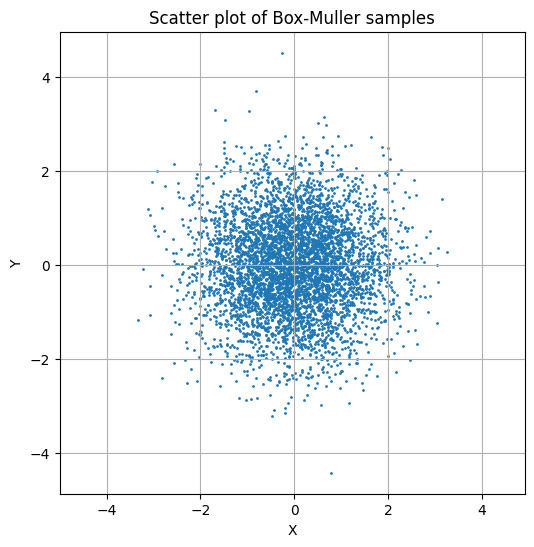

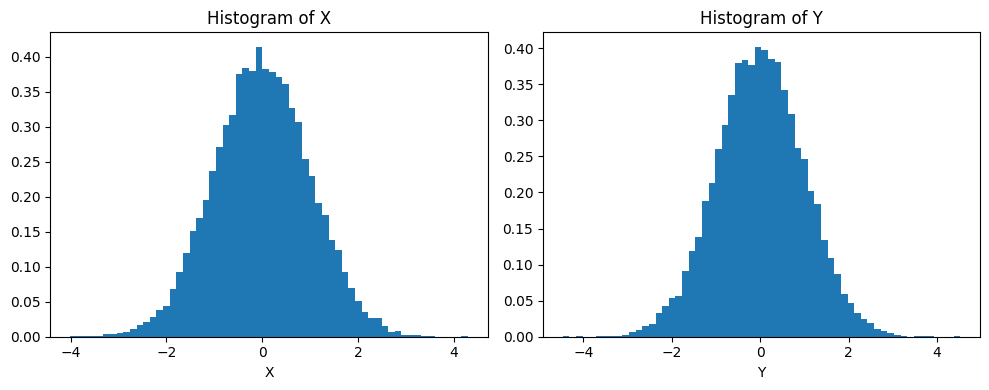

Mean of X: -0.0014709192570256497
Variance of X: 0.9966697744492651
Mean of Y: -0.0008264173587719188
Variance of Y: 0.9782593828513276


In [47]:
import numpy as np
import matplotlib.pyplot as plt

n = 20000

U1 = np.random.rand(n)
U2 = np.random.rand(n)

Theta = 2 * np.pi * U1
R = np.sqrt(-2 * np.log(U2))

X = R * np.cos(Theta)
Y = R * np.sin(Theta)

#Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(X[:5000], Y[:5000], s=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter plot of Box-Muller samples")
plt.axis("equal")
plt.grid(True)
plt.show()

#Marginal histograms
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(X, bins=60, density=True)
plt.title("Histogram of X")
plt.xlabel("X")

plt.subplot(1, 2, 2)
plt.hist(Y, bins=60, density=True)
plt.title("Histogram of Y")
plt.xlabel("Y")

plt.tight_layout()
plt.show()

#Sample statistics
print("Mean of X:", np.mean(X))
print("Variance of X:", np.var(X))
print("Mean of Y:", np.mean(Y))
print("Variance of Y:", np.var(Y))
